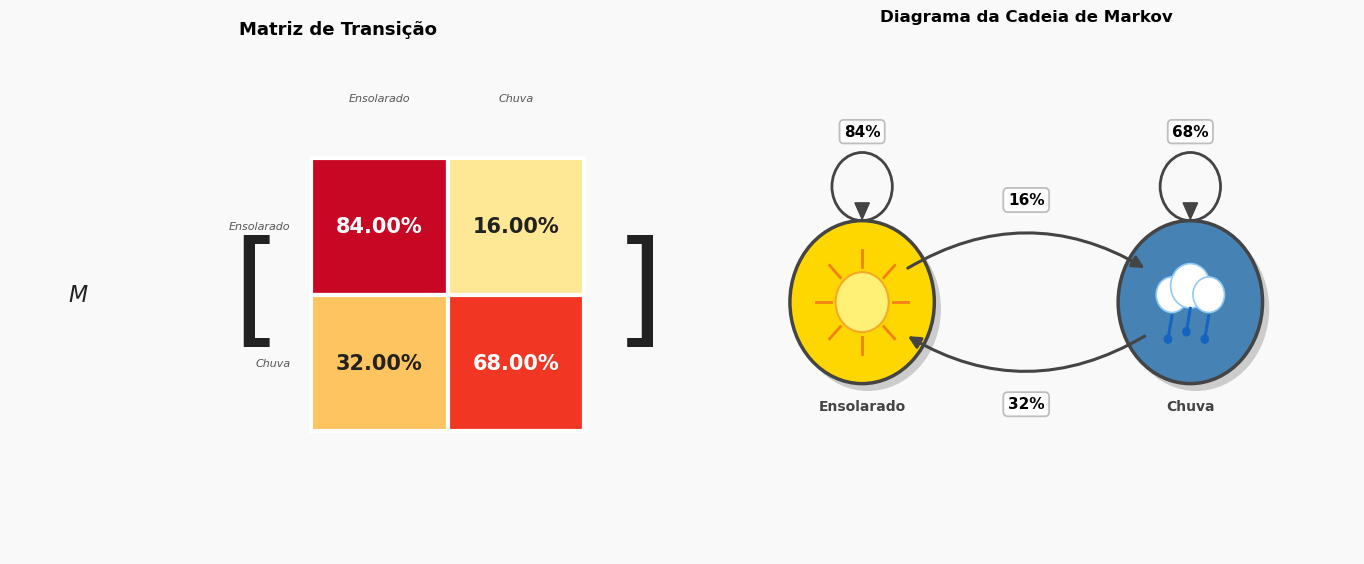

Estado estacionário (longo prazo):
  Ensolarado ☀️: 66.7%  █████████████
  Chuvoso 🌧️: 33.3%  ██████


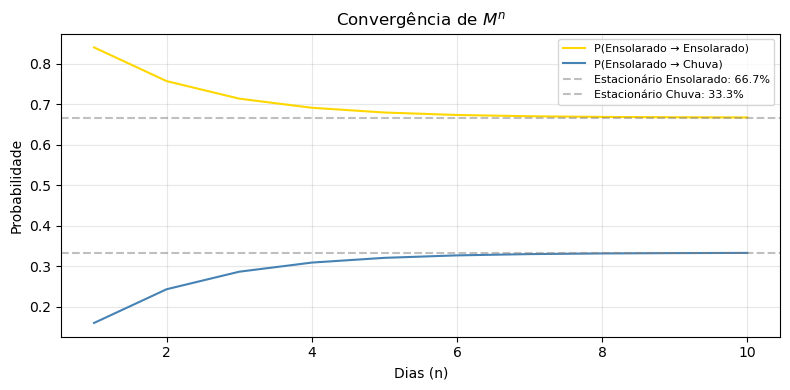


Previsão para daqui 10 dia(s):
  Ensolarado ☀️     : 66.7%  █████████████
  Chuvoso 🌧️        : 66.6%  █████████████


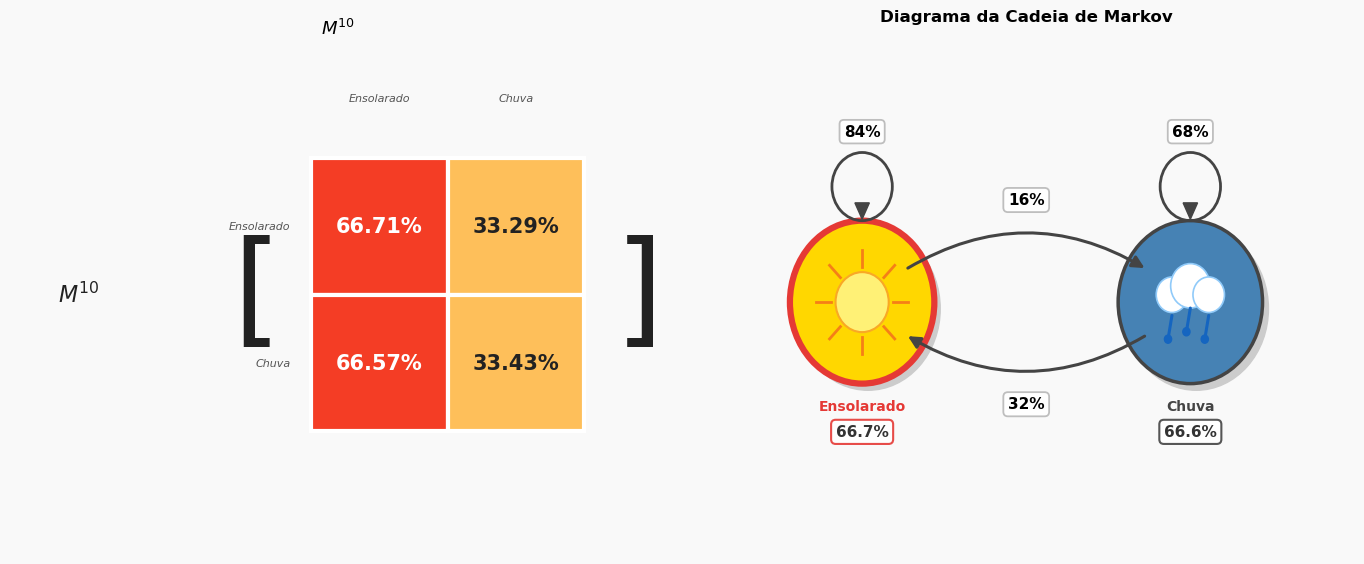

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sympy as sp

# ══════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════
ESTADOS     = ["Ensolarado ☀️", "Chuvoso 🌧️"]   # com emoji — usado em print
ESTADOS_IMG = ["Ensolarado", "Chuva"]             # sem emoji — usado em matplotlib
CORES       = ["#FFD700", "#4682B4"]

M = np.array([[0.84, 0.16],
              [0.32, 0.68]])

assert np.allclose(M.sum(axis=1), 1), "A matriz de transição não é estocástica!"

autovalores, autovetores = np.linalg.eig(M)

# Estado estacionário: autovetor ESQUERDO de M (autovetor direito de M.T)
avals_T, avecs_T = np.linalg.eig(M.T)
idx_T = np.argmin(np.abs(avals_T - 1.0))
estacionario = np.abs(avecs_T[:, idx_T])
estacionario /= estacionario.sum()


# ══════════════════════════════════════════════════════════
# FUNÇÕES DE VISUALIZAÇÃO
# ══════════════════════════════════════════════════════════
def _icone_sol(ax, cx, cy, r_externo=0.9, zorder=4):
    """Desenha um sol com raios dentro do nó."""
    ax.add_patch(plt.Circle((cx, cy), r_externo * 0.45,
                             color="#FFF176", ec="#F9A825", lw=1.5, zorder=zorder))
    for ang in range(0, 360, 45):
        rad = np.radians(ang)
        r1, r2 = r_externo * 0.52, r_externo * 0.78
        ax.plot([cx + r1*np.cos(rad), cx + r2*np.cos(rad)],
                [cy + r1*np.sin(rad), cy + r2*np.sin(rad)],
                color="#F57F17", lw=2, zorder=zorder)


def _icone_chuva(ax, cx, cy, r=0.9, zorder=4):
    """Desenha uma nuvem com gotas dentro do nó."""
    # Nuvem: 3 círculos sobrepostos
    for dx, dy, rc in [(-0.28, 0.1, 0.24), (0, 0.22, 0.30), (0.28, 0.1, 0.24)]:
        ax.add_patch(plt.Circle((cx+dx, cy+dy), rc,
                                 color="white", ec="#90CAF9", lw=1.2, zorder=zorder))
    # Gotas de chuva
    for gx, gy in [(-0.28, -0.18), (0, -0.08), (0.28, -0.18)]:
        ax.plot([cx+gx, cx+gx-0.06], [cy+gy, cy+gy-0.32],
                color="#1565C0", lw=2.2, solid_capstyle="round", zorder=zorder+1)
        ax.add_patch(plt.Circle((cx+gx-0.06, cy+gy-0.32), 0.055,
                                 color="#1565C0", zorder=zorder+1))


def _desenhar_diagrama(ax, probs_saida=None, estado_inicial=None):
    R = 1.1   # raio do nó
    ax.set_xlim(0, 10); ax.set_ylim(0.2, 7.2); ax.axis("off")
    ax.set_facecolor("#f0f4f8")
    ax.set_title("Diagrama da Cadeia de Markov", fontsize=12, fontweight="bold", pad=10)

    POS = [(2.5, 3.6), (7.5, 3.6)]

    # ── Nós ──────────────────────────────────────────────
    for idx_no, ((x, y), cor) in enumerate(zip(POS, CORES)):
        destacado = idx_no == estado_inicial
        borda = "#E53935" if destacado else "#444"
        lw    = 4.5      if destacado else 2.5

        # Sombra
        ax.add_patch(plt.Circle((x+0.09, y-0.09), R, color="#ccc", zorder=2))
        # Nó principal
        ax.add_patch(plt.Circle((x, y), R, color=cor, ec=borda, lw=lw, zorder=3))

        # Ícone dentro do nó
        if idx_no == 0:
            _icone_sol(ax, x, y, zorder=4)
        else:
            _icone_chuva(ax, x, y, zorder=4)

        # Nome do estado abaixo do nó
        ax.text(x, y - R - 0.22, ESTADOS_IMG[idx_no],
                ha="center", va="top", fontsize=10, fontweight="bold",
                color=borda, zorder=5)

        # Probabilidade prevista (se houver)
        if probs_saida is not None:
            ax.text(x, y - R - 0.55, f"{probs_saida[idx_no]:.1%}",
                    ha="center", va="top", fontsize=11, fontweight="bold",
                    color="#333", zorder=5,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white",
                              ec=borda, lw=1.5, alpha=0.9))

    # ── Auto-laços ───────────────────────────────────────
    LOOP_R = 0.46
    for (x, y), i in zip(POS, [0, 1]):
        lx, ly = x, y + R + LOOP_R   # centro do círculo do laço
        ax.add_patch(plt.Circle((lx, ly), LOOP_R,
                                 fill=False, ec="#444", lw=2, zorder=4))
        # Seta apontando para baixo, na junção com o nó
        tip   = np.array([x,        y + R + 0.02])
        left  = np.array([x - 0.11, y + R + 0.24])
        right = np.array([x + 0.11, y + R + 0.24])
        ax.add_patch(plt.Polygon([tip, left, right],
                                  closed=True, fc="#444", ec="#444", zorder=5))
        # Label acima do laço
        ax.text(x, ly + LOOP_R + 0.18, f"{M[i,i]:.0%}",
                ha="center", va="bottom", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.28", fc="white",
                          ec="#bbb", lw=1.3, alpha=0.95), zorder=6)

    # ── Setas entre estados ──────────────────────────────
    def seta(p1, p2, label, rad):
        ax.annotate("", xy=p2, xytext=p1,
                    arrowprops=dict(arrowstyle="-|>", color="#444", lw=2.2,
                                    mutation_scale=18,
                                    connectionstyle=f"arc3,rad={rad}"), zorder=5)
        mx = (p1[0]+p2[0])/2 + rad*(p2[1]-p1[1])*0.85
        my = (p1[1]+p2[1])/2 - rad*(p2[0]-p1[0])*0.85
        ax.text(mx, my, label, ha="center", va="center",
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec="#bbb", lw=1.3, alpha=0.95), zorder=6)

    x0, y0 = POS[0]
    x1, y1 = POS[1]
    seta((x0 + R*0.6, y0 + R*0.4), (x1 - R*0.6, y1 + R*0.4), f"{M[0,1]:.0%}", rad=-0.3)
    seta((x1 - R*0.6, y1 - R*0.4), (x0 + R*0.6, y0 - R*0.4), f"{M[1,0]:.0%}", rad=-0.3)


def _desenhar_matriz(ax, dados, titulo_ax, rotulo_esq, eh_simbolico=False):
    n = len(ESTADOS_IMG)
    ax.set_xlim(-2.2, n + 0.6); ax.set_ylim(-0.8, n + 0.8)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(titulo_ax, fontsize=13, fontweight="bold", pad=10)
    ax.set_facecolor("#f9f9f9")

    for j, e in enumerate(ESTADOS_IMG):
        ax.text(j+0.5, n+0.4, e, ha="center", va="bottom", fontsize=8, color="#555", style="italic")
    for i, e in enumerate(ESTADOS_IMG):
        ax.text(-0.15, n-1-i+0.5, e, ha="right", va="center", fontsize=8, color="#555", style="italic")

    cmap = plt.cm.YlOrRd
    for i in range(n):
        for j in range(n):
            if eh_simbolico:
                entry  = sp.nsimplify(dados[i, j], rational=True, tolerance=1e-8)
                entry  = sp.simplify(entry)
                txt    = f"${sp.latex(entry)}$"
                bg_cor = "#ddeeff"; txt_cor = "#111"; fs = 9
            else:
                val    = float(np.real(dados[i, j]))
                txt    = f"{val:.2%}"
                bg_cor = cmap(np.clip(val, 0, 1))
                txt_cor = "white" if val > 0.55 else "#222"; fs = 15

            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                        facecolor=bg_cor, edgecolor="white", lw=3, zorder=2))
            ax.text(j+0.5, n-1-i+0.5, txt, ha="center", va="center",
                    fontsize=fs, fontweight="bold", color=txt_cor, zorder=3)

    ax.text(-0.4,  n/2, "[", ha="center", va="center", fontsize=90, color="#222", fontfamily="DejaVu Sans")
    ax.text(n+0.4, n/2, "]", ha="center", va="center", fontsize=90, color="#222", fontfamily="DejaVu Sans")
    ax.text(-1.7,  n/2, rotulo_esq, ha="center", va="center",
            fontsize=16, fontweight="bold", color="#222")


def mostrar_visualizacao_inicial():
    fig, (ax_mat, ax_diag) = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("#f9f9f9")
    _desenhar_matriz(ax_mat, M, "Matriz de Transição", "$M$")
    _desenhar_diagrama(ax_diag)
    plt.tight_layout(pad=2); plt.show()
    print("Estado estacionário (longo prazo):")
    for e, p in zip(ESTADOS, estacionario):
        barra = "█" * int(p * 20)
        print(f"  {e}: {p:.1%}  {barra}")


def mostrar_resultado(Mn, n_label, estado_idx):
    eh_simbolico = not isinstance(Mn, np.ndarray)
    titulo_ax  = "$M^n$  (simbólico)" if eh_simbolico else f"$M^{{{n_label}}}$"
    rotulo_esq = "$M^n$"             if eh_simbolico else f"$M^{{{n_label}}}$"

    fig, (ax_mat, ax_diag) = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("#f9f9f9")
    _desenhar_matriz(ax_mat, Mn, titulo_ax, rotulo_esq, eh_simbolico=eh_simbolico)

    if eh_simbolico:
        _desenhar_diagrama(ax_diag, estado_inicial=estado_idx)
    else:
        v0 = np.zeros(len(ESTADOS)); v0[estado_idx] = 1.0
        probs = (Mn @ v0).real
        _desenhar_diagrama(ax_diag, probs_saida=probs, estado_inicial=estado_idx)
        print(f"\nPrevisão para daqui {n_label} dia(s):")
        for e, p in zip(ESTADOS, probs):
            barra = "█" * int(p * 20)
            print(f"  {e:18s}: {p:.1%}  {barra}")

    plt.tight_layout(pad=2); plt.show()


# ══════════════════════════════════════════════════════════
# FUNÇÕES DE CÁLCULO
# ══════════════════════════════════════════════════════════
def potencia_matriz(n_input):
    P     = np.array(autovetores, dtype=complex)
    P_inv = np.linalg.inv(P)

    try:
        n = int(n_input)
        if n <= 0:
            raise ValueError("n deve ser positivo")

        historico = np.array([
            (P @ np.diag(autovalores**k) @ P_inv).real
            for k in range(1, n + 1)
        ])

        fig, ax = plt.subplots(figsize=(8, 4))
        for i, (e, cor) in enumerate(zip(ESTADOS_IMG, ["gold", "steelblue"])):
            ax.plot(range(1, n+1), historico[:, 0, i], label=f"P({ESTADOS_IMG[0]} → {e})", color=cor)
        for i, prob in enumerate(estacionario):
            ax.axhline(y=prob, color="gray", linestyle="--", alpha=0.5,
                       label=f"Estacionário {ESTADOS_IMG[i]}: {prob:.1%}")
        ax.set_xlabel("Dias (n)"); ax.set_ylabel("Probabilidade")
        ax.set_title("Convergência de $M^n$")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        return (P @ np.diag(autovalores**n) @ P_inv).real

    except ValueError:
        n_sym   = sp.sympify(n_input)
        P_sym   = sp.Matrix(np.array(autovetores).tolist())
        lambdas = [sp.nsimplify(v.real, rational=True, tolerance=1e-8) for v in autovalores]
        D_sym   = sp.diag(*lambdas)
        return sp.simplify(P_sym * (D_sym**n_sym) * P_sym.inv())


# ══════════════════════════════════════════════════════════
# EXECUÇÃO
# ══════════════════════════════════════════════════════════
mostrar_visualizacao_inicial()

n_input      = input("\nDaqui quantos dias você quer saber a previsão do tempo? ")
opcoes       = " / ".join(f"{i}={e}" for i, e in enumerate(ESTADOS))
estado_input = input(f"Qual o tempo hoje? ({opcoes}): ")

Mn = potencia_matriz(n_input)
mostrar_resultado(Mn, n_input, int(estado_input))
